In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [84]:
PCAWG = '../out/PCAWG_fit.tsv'
sample = '../out/sample_fitness.tsv'

use_sample = False

data = pd.read_csv(PCAWG if use_sample else sample, sep='\t', index_col=0)
data["TsgOg"] = data["Tsg"] + data["Og"]
columns = ["Fitness", "Stress", "Essentiality", "Tsg", "Og", "TsgOg"]
data.head()


,Fitness,Stress,Tsg,Og,Essentiality,TsgOg
Id,,,,,,
0-0,1.0256,0.0000,2.5617,0.0000,0.0,2.5617
10-0,1.0563,0.0115,22.6583,-18.1759,0.0,4.4824
51-0,1.0150,0.0399,52.0833,-54.5754,0.0,-2.4921
113-0,0.8703,0.0884,102.3794,-124.1913,0.0,-21.8119
420-0,0.9964,0.0778,94.2282,-102.3639,0.0,-8.1357


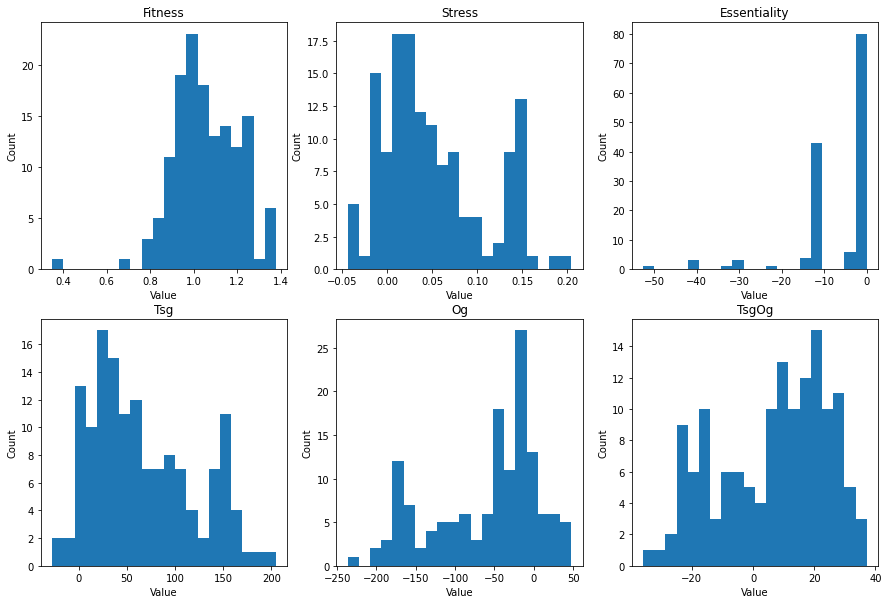

In [85]:
bin_count = 50 if use_sample else 20

# create 6 subplots 2*3
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# plot the data
for x in range(2):
    for y in range(3):
        axes[x, y].set_xlabel('Value')
        axes[x, y].set_ylabel('Count')
        axes[x, y].set_title(columns[x*3+y])    
        axes[x, y].hist(data[columns[x*3+y]], bins=bin_count)

Text(0.5, 0, '$\\Delta(F)$')

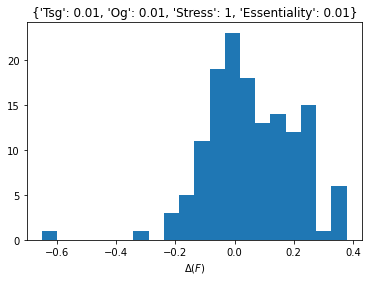

In [91]:
params =  {"Tsg": 0.01, "Og": 0.01, "Stress": 1, "Essentiality": 0.01 }
myfun = lambda x : (params[x] * data[x]).to_numpy()
mySum = sum(map(myfun, params.keys()))
plt.title(f"{params}")
plt.hist(mySum, bins=bin_count);
plt.xlabel('$\Delta(F)$')

Text(0, 0.5, 'Og')

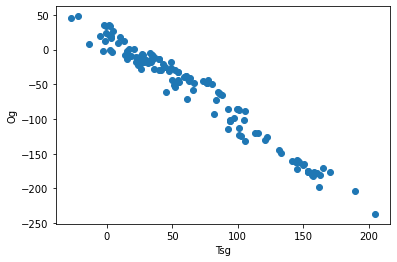

In [90]:
plt.scatter(data["Tsg"], data["Og"]);
plt.xlabel("Tsg")
plt.ylabel("Og")

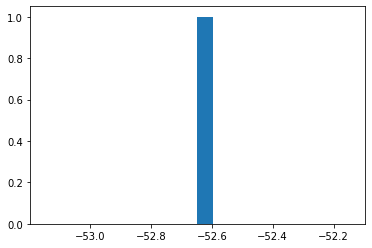

In [88]:
plt.hist(data["Essentiality"][data["Essentiality"] < -50], bins=bin_count);